## Analysing results from Stormer run between 23 Jan to 30 March 2020

In [1]:
import glob as _glob
from collections import defaultdict
import torch
import os
from stormer.utils.metrics import lat_weighted_rmse
import numpy as np

In [2]:
out_dir = 'results'

In [76]:
from stormer.models.hub.stormer import Stormer
from stormer.data.multi_step_datamodule import collate_fn_val
from stormer.models.iterative_module import GlobalForecastIterativeModule
from torchvision.transforms import transforms

variables = [
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "mean_sea_level_pressure",
    "geopotential_50",
    "geopotential_100",
    "geopotential_150",
    "geopotential_200",
    "geopotential_250",
    "geopotential_300",
    "geopotential_400",
    "geopotential_500",
    "geopotential_600",
    "geopotential_700",
    "geopotential_850",
    "geopotential_925",
    "geopotential_1000",
    "u_component_of_wind_50",
    "u_component_of_wind_100",
    "u_component_of_wind_150",
    "u_component_of_wind_200",
    "u_component_of_wind_250",
    "u_component_of_wind_300",
    "u_component_of_wind_400",
    "u_component_of_wind_500",
    "u_component_of_wind_600",
    "u_component_of_wind_700",
    "u_component_of_wind_850",
    "u_component_of_wind_925",
    "u_component_of_wind_1000",
    "v_component_of_wind_50",
    "v_component_of_wind_100",
    "v_component_of_wind_150",
    "v_component_of_wind_200",
    "v_component_of_wind_250",
    "v_component_of_wind_300",
    "v_component_of_wind_400",
    "v_component_of_wind_500",
    "v_component_of_wind_600",
    "v_component_of_wind_700",
    "v_component_of_wind_850",
    "v_component_of_wind_925",
    "v_component_of_wind_1000",
    "temperature_50",
    "temperature_100",
    "temperature_150",
    "temperature_200",
    "temperature_250",
    "temperature_300",
    "temperature_400",
    "temperature_500",
    "temperature_600",
    "temperature_700",
    "temperature_850",
    "temperature_925",
    "temperature_1000",
    "specific_humidity_50",
    "specific_humidity_100",
    "specific_humidity_150",
    "specific_humidity_200",
    "specific_humidity_250",
    "specific_humidity_300",
    "specific_humidity_400",
    "specific_humidity_500",
    "specific_humidity_600",
    "specific_humidity_700",
    "specific_humidity_850",
    "specific_humidity_925",
    "specific_humidity_1000",
]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f'device: {device}', flush=True)
# load pretrained model
net = Stormer(
    in_img_size=[128, 256],
    variables=variables,
    patch_size=4,
    hidden_size=1024,
    depth=24,
    num_heads=16,
    mlp_ratio=4,
)
pretrained_path = r'C:\Users\maxsh\Stormer\stormer_1.40625_patch_size_4.ckpt'
model = GlobalForecastIterativeModule(net, pretrained_path=pretrained_path).to(device)
model.eval()
print(f'model loaded!', flush=True)


root_dir = r'C:\Users\maxsh\era5_processed'
norm_dir = r'C:\Users\maxsh\Stormer\stormer\normalization_constants'
normalize_mean = dict(np.load(os.path.join(norm_dir, "normalize_mean.npz")))
normalize_mean = np.concatenate([normalize_mean[v] for v in variables], axis=0)
normalize_std = dict(np.load(os.path.join(norm_dir, "normalize_std.npz")))
normalize_std = np.concatenate([normalize_std[v] for v in variables], axis=0)
inp_transform = transforms.Normalize(normalize_mean, normalize_std)

# Data normalisations
out_transforms = {}
for l in [6, 12, 24]:
    normalize_diff_std = dict(np.load(os.path.join(norm_dir, f"normalize_diff_std_{l}.npz")))
    normalize_diff_std = np.concatenate([normalize_diff_std[v] for v in variables], axis=0)
    out_transforms[l] = transforms.Normalize(np.zeros_like(normalize_diff_std), normalize_diff_std)
model.set_transforms(inp_transform, out_transforms)

lat = np.load(os.path.join(root_dir, "lat.npy"))
lon = np.load(os.path.join(root_dir, "lon.npy"))

c:\Users\maxsh\Stormer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0510 12:19:21.802000 6236 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
A matching Triton is not available, some optimizations will not be enabled
Traceback (most recent call last):
  File "c:\Users\maxsh\Stormer\.venv\Lib\site-packages\xformers\__init__.py", line 57, in _is_triton_available
    import triton  # noqa
    ^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'triton'


device: cuda
Loading pre-trained checkpoint from: C:\Users\maxsh\Stormer\stormer_1.40625_patch_size_4.ckpt
<All keys matched successfully>
model loaded!


NameError: name 'np' is not defined

In [4]:
def lat_weighted_var(field, lat):
    """Latitude-weighted variance of a field with shape (..., Nlat, Nlon).
    lat is a 1D array of latitudes in degrees, length Nlat. Uses cos(lat)
    weights to correct for grid cells getting smaller toward the poles."""
    field = np.asarray(field, dtype=np.float64)
    w = np.cos(np.deg2rad(lat))
    weights = w[:, None] / (w.sum() * field.shape[-1])  # (Nlat, 1), sums to 1
    mean = (field * weights).sum(axis=(-2, -1), keepdims=True)
    return ((field - mean) ** 2 * weights).sum(axis=(-2, -1))


In [60]:
init_times = []
rmse_by_lead = defaultdict(lambda: defaultdict(list))
ratio_per_lead = defaultdict(lambda: defaultdict(list))

for fpath in sorted(_glob.glob(os.path.join(out_dir, '20*.pt'))):
    blob = torch.load(fpath, weights_only=False)
    init_times.append(blob['init_time'])
    for lead_time, data in blob['results'].items():
        # promote back to fp32 for the metric computation
        pred = torch.from_numpy(data['pred']).float()
        gt = torch.from_numpy(data['gt']).float()
        rmse = lat_weighted_rmse(pred, gt, model.reverse_inp_transform, variables, lat, log_postfix=str(lead_time))
        for i, vari in enumerate(variables):
            rmse_by_lead[lead_time][vari].append(rmse[f"w_rmse_{vari}_{lead_time}"])
            v_pred = lat_weighted_var(pred[0, i].numpy(), lat)
            v_gt = lat_weighted_var(gt[0, i].numpy(), lat)
            ratio_per_lead[lead_time][vari].append(v_pred / v_gt)


In [30]:
pred.shape

torch.Size([1, 69, 128, 256])

In [61]:
rmse_per_init = {
    lt: {v: torch.stack(vals).cpu() for v, vals in by_var.items()}
    for lt, by_var in rmse_by_lead.items()
}
mean_rmses = {
    lt: {v: t.mean().item() for v, t in by_var.items()}
    for lt, by_var in rmse_per_init.items()
}

ratio_per_init = {
    lt: {v: np.asarray(vals) for v, vals in by_var.items()}
    for lt, by_var in ratio_per_lead.items()
}
mean_ratios = {
    lt: {v: float(a.mean()) for v, a in by_var.items()}
    for lt, by_var in ratio_per_init.items()
}


In [62]:
mean_ratios

{24: {'2m_temperature': 1.0031984886498015,
  '10m_u_component_of_wind': 0.9981480509542545,
  '10m_v_component_of_wind': 0.9994848405431972,
  'mean_sea_level_pressure': 1.001768644288433,
  'geopotential_50': 0.9925932706099775,
  'geopotential_100': 0.997851266989124,
  'geopotential_150': 0.9989905360779834,
  'geopotential_200': 0.9998236595150125,
  'geopotential_250': 1.0003874882063961,
  'geopotential_300': 1.0005824752653132,
  'geopotential_400': 1.0002409536727186,
  'geopotential_500': 0.9992181501074656,
  'geopotential_600': 0.9982681259304068,
  'geopotential_700': 0.9973639056604411,
  'geopotential_850': 0.9989244315537756,
  'geopotential_925': 0.9997582797631638,
  'geopotential_1000': 1.0008769102854889,
  'u_component_of_wind_50': 1.0027404468659817,
  'u_component_of_wind_100': 0.9811279916230577,
  'u_component_of_wind_150': 0.9769583607406035,
  'u_component_of_wind_200': 0.9813813167306618,
  'u_component_of_wind_250': 0.9881041160367251,
  'u_component_of_win

In [24]:
rmse_per_init

{24: {'2m_temperature': tensor([0.6400, 0.6597, 0.6662, 0.6126, 0.6074, 0.6207, 0.6296, 0.6298, 0.6354,
          0.6439, 0.6522, 0.6389, 0.6488, 0.6319, 0.6474, 0.6264, 0.6134, 0.6305,
          0.6276, 0.6415, 0.6390, 0.6232, 0.6417, 0.6282, 0.6468, 0.6490, 0.6195,
          0.6254, 0.6351, 0.6207, 0.6480, 0.6499, 0.6402, 0.6470, 0.6471, 0.6628,
          0.6305, 0.6601, 0.6530, 0.6338, 0.6520, 0.6310, 0.6414, 0.6428, 0.6424,
          0.6302, 0.6501, 0.6266, 0.6374, 0.6504, 0.6339, 0.6196, 0.6369, 0.6141,
          0.6125, 0.6203, 0.6209, 0.6103, 0.6164, 0.6092, 0.6258, 0.6062, 0.6135,
          0.6268, 0.6388, 0.6285, 0.6462, 0.6276, 0.6520, 0.6447, 0.6260, 0.6300,
          0.6442, 0.6155, 0.6691, 0.6646, 0.6343, 0.6410, 0.6483, 0.6591, 0.6239,
          0.6303, 0.6527, 0.6545, 0.6371, 0.6218, 0.6348, 0.6242, 0.6048, 0.6279,
          0.6315, 0.6503, 0.6444, 0.6605, 0.6546, 0.6542, 0.6315, 0.6692, 0.6282,
          0.6730, 0.6215, 0.6213, 0.6105, 0.6157, 0.6109, 0.6504, 0.6334, 0.

In [ ]:
mean_rmses

{24: {'2m_temperature': 0.6350440382957458,
  '10m_u_component_of_wind': 0.7665846943855286,
  '10m_v_component_of_wind': 0.8040754795074463,
  'mean_sea_level_pressure': 60.27684020996094,
  'geopotential_50': 132.8780059814453,
  'geopotential_100': 82.03266143798828,
  'geopotential_150': 68.65695190429688,
  'geopotential_200': 65.62399291992188,
  'geopotential_250': 66.80976867675781,
  'geopotential_300': 68.09965515136719,
  'geopotential_400': 60.24007034301758,
  'geopotential_500': 51.2611083984375,
  'geopotential_600': 45.760013580322266,
  'geopotential_700': 43.6646614074707,
  'geopotential_850': 43.10930252075195,
  'geopotential_925': 44.407615661621094,
  'geopotential_1000': 47.37089920043945,
  'u_component_of_wind_50': 2.1005542278289795,
  'u_component_of_wind_100': 2.0966572761535645,
  'u_component_of_wind_150': 2.188171148300171,
  'u_component_of_wind_200': 2.2937793731689453,
  'u_component_of_wind_250': 2.352081775665283,
  'u_component_of_wind_300': 2.3081

#### Maybe plot some imshow graphs here after

#### Analysis into spectral measurements

In [5]:
import scipy

In [7]:
result_file = 'results/20200101_00.pt'
data_blob = torch.load(result_file, weights_only=False)

var_idx = 67
pred_field = data_blob['results'][168]['pred'][0, var_idx]
gt_field = data_blob['results'][168]['gt'][0, var_idx]

In [ ]:
def calculatePsd(field):
    # Removes DC component
    field = field - np.mean(field)
    f_transform = np.fft.fft2(field)
    f_shifted = np.fft.fftshift(f_transform)
    power_spectrum = np.abs(f_shifted)**2

    Ny, Nx = power_spectrum.shape
    cy, cx = Ny//2, Nx//2
    y, x = np.indices(power_spectrum.shape)

    r = np.sqrt((x-cx)**2 + (y-cy)**2).astype(int)
    power_sum_per_radius = np.bincount(r.ravel(), weights=power_spectrum.ravel())
    pixel_count_per_radius = np.bincount(r.ravel())
    psd_1d = power_sum_per_radius / pixel_count_per_radius
    wavenumbers = np.arange(len(psd_1d))
    return wavenumbers, psd_1d


In [15]:
def zonal_psd(field):
    f = field - field.mean(axis=-1, keepdims=True)
    F = np.fft.rfft(f, axis=-1)
    return np.arange(1, F.shape[-1]), (np.abs(F)**2).mean(axis=0)[1:]


In [9]:
import matplotlib.pyplot as plt

wavenumbers_pred, psd_1d_pred = zonal_psd(pred_field)
wavenumbers_gt, psd_1d_gt = zonal_psd(gt_field)

plt.loglog(wavenumbers_pred, psd_1d_pred, label = "Pred")
plt.loglog(wavenumbers_gt, psd_1d_gt, label = "gt")
plt.xlabel('Wavenumber (1/L)')
plt.ylabel('Power')
plt.title('Isotropic Power Spectral Density')
plt.legend()
plt.show()

NameError: name 'zonal_psd' is not defined

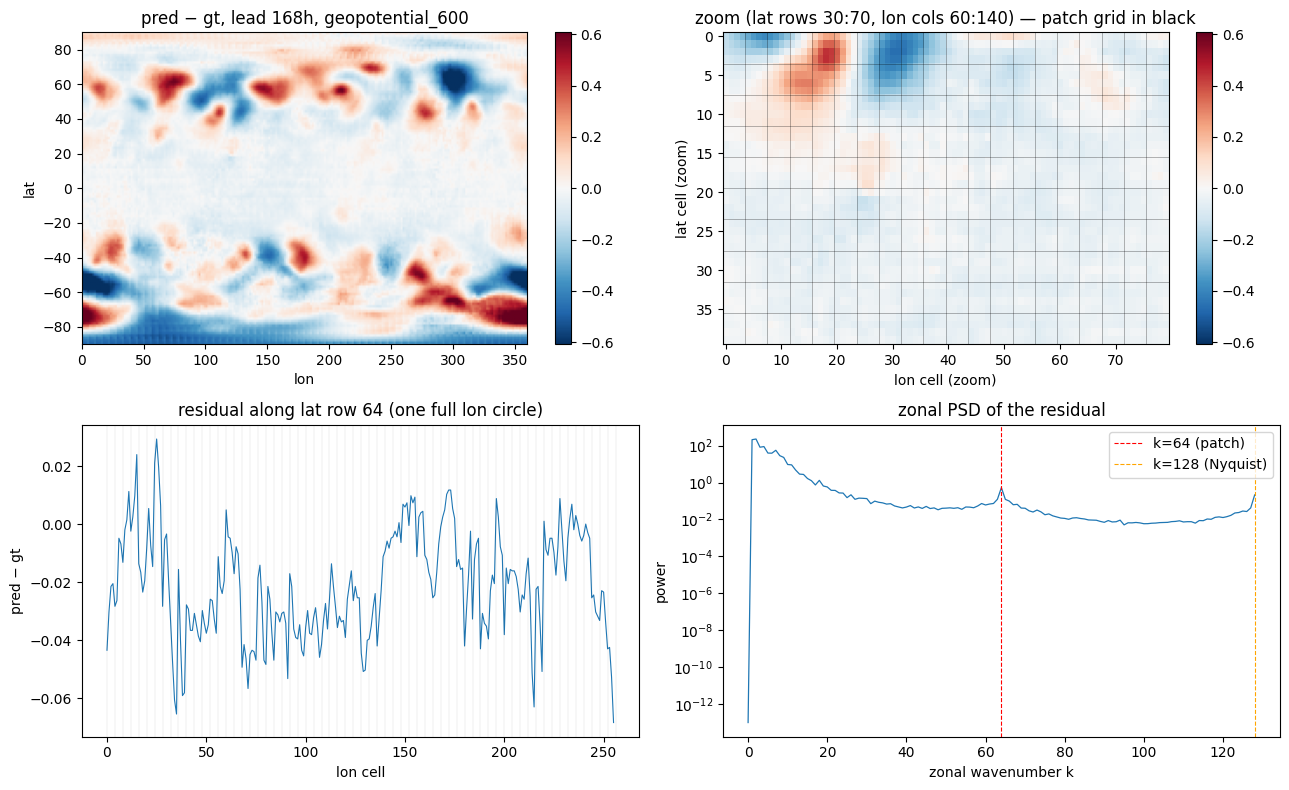

In [17]:
lt = 168
var = 12  # 10m_u_component_of_wind
pred = data_blob['results'][lt]['pred'][0, var].astype(np.float32)
gt   = data_blob['results'][lt]['gt'][0, var].astype(np.float32)
resid = pred - gt

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
vmax = np.percentile(np.abs(resid), 99)

# (a) full residual map
im0 = axes[0, 0].imshow(resid, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                        extent=[0, 360, -90, 90], origin='upper', aspect='auto')
axes[0, 0].set_title(f'pred − gt, lead {lt}h, {variables[var]}')
axes[0, 0].set_xlabel('lon'); axes[0, 0].set_ylabel('lat')
plt.colorbar(im0, ax=axes[0, 0])

# (b) zoom into a mid-latitude band, with patch boundaries marked
y0, y1, x0, x1 = 30, 70, 60, 140
zoom = resid[y0:y1, x0:x1]
im1 = axes[0, 1].imshow(zoom, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
axes[0, 1].set_title(f'zoom (lat rows {y0}:{y1}, lon cols {x0}:{x1}) — patch grid in black')
axes[0, 1].set_xlabel('lon cell (zoom)'); axes[0, 1].set_ylabel('lat cell (zoom)')
for x in range(0, x1 - x0 + 1, 4):
    axes[0, 1].axvline(x - 0.5, color='k', lw=0.4, alpha=0.5)
for y in range(0, y1 - y0 + 1, 4):
    axes[0, 1].axhline(y - 0.5, color='k', lw=0.4, alpha=0.5)
plt.colorbar(im1, ax=axes[0, 1])

# (c) 1D slice along one latitude row, with patch boundaries
row = 64
axes[1, 0].plot(resid[row], lw=0.8)
axes[1, 0].set_title(f'residual along lat row {row} (one full lon circle)')
axes[1, 0].set_xlabel('lon cell'); axes[1, 0].set_ylabel('pred − gt')
for x in range(0, 257, 4):
    axes[1, 0].axvline(x, color='k', lw=0.15, alpha=0.3)

# (d) zonal PSD of the residual itself — should peak at k=64 and k=128
F = np.fft.rfft(resid - resid.mean(axis=-1, keepdims=True), axis=-1)
psd_resid = (np.abs(F) ** 2).mean(axis=0)
axes[1, 1].semilogy(np.arange(psd_resid.size), psd_resid, lw=0.9)
axes[1, 1].axvline(64, color='r', lw=0.8, ls='--', label='k=64 (patch)')
axes[1, 1].axvline(128, color='orange', lw=0.8, ls='--', label='k=128 (Nyquist)')
axes[1, 1].set_xlabel('zonal wavenumber k'); axes[1, 1].set_ylabel('power')
axes[1, 1].set_title('zonal PSD of the residual')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [17]:
import glob as _glob
from collections import defaultdict

LEVELS_HPA  = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
U_OFFSET, V_OFFSET = 17, 30   # u_50..u_1000 are channels 17..29, v at 30..42

def zonal_ke_spectrum(u, v, lat, lat_band=(-60, 60)):
    """KE-per-unit-mass spectrum: 0.5*(|U_k|^2 + |V_k|^2), lat-band-averaged with cos(lat)."""
    fu = u - u.mean(axis=-1, keepdims=True)
    fv = v - v.mean(axis=-1, keepdims=True)
    Fu = np.fft.rfft(fu, axis=-1) / fu.shape[-1]   # so |F_k|^2 has units of variance
    Fv = np.fft.rfft(fv, axis=-1) / fv.shape[-1]
    ke = 0.5 * (np.abs(Fu)**2 + np.abs(Fv)**2)     # (Nlat, k)
    mask = (lat >= lat_band[0]) & (lat <= lat_band[1])
    w = np.cos(np.deg2rad(lat[mask]))
    ke_avg = (ke[mask] * w[:, None]).sum(0) / w.sum()
    return np.arange(1, ke_avg.size), ke_avg[1:]    # drop k=0 (mean wind)

# pred/gt are saved in NORMALIZED space — un-normalize for physical m^2/s^2
def denorm(field_2d, ch):
    return field_2d * normalize_std[ch] + normalize_mean[ch]

level_idx = LEVELS_HPA.index(500)
ui, vi = U_OFFSET + level_idx, V_OFFSET + level_idx

ke_pred_by_lt = defaultdict(list)
ke_gt_by_lt   = defaultdict(list)
k_axis = None

for fpath in sorted(_glob.glob(os.path.join(out_dir, '20*.pt'))):
    blob = torch.load(fpath, weights_only=False)
    for lt, data in blob['results'].items():
        pred = data['pred'][0]; gt = data['gt'][0]   # (69, 128, 256)
        u_p, v_p = denorm(pred[ui], ui), denorm(pred[vi], vi)
        u_g, v_g = denorm(gt[ui],   ui), denorm(gt[vi],   vi)
        k, ep = zonal_ke_spectrum(u_p, v_p, lat)
        _, eg = zonal_ke_spectrum(u_g, v_g, lat)
        ke_pred_by_lt[lt].append(ep); ke_gt_by_lt[lt].append(eg); k_axis = k

ke_pred_mean = {lt: np.mean(np.stack(v), 0) for lt, v in ke_pred_by_lt.items()}
ke_gt_mean   = {lt: np.mean(np.stack(v), 0) for lt, v in ke_gt_by_lt.items()}
print(f"averaged over {len(next(iter(ke_pred_by_lt.values())))} init times, "
      f"lead times: {sorted(ke_pred_mean)}")


averaged over 138 init times, lead times: [24, 72, 120, 168]


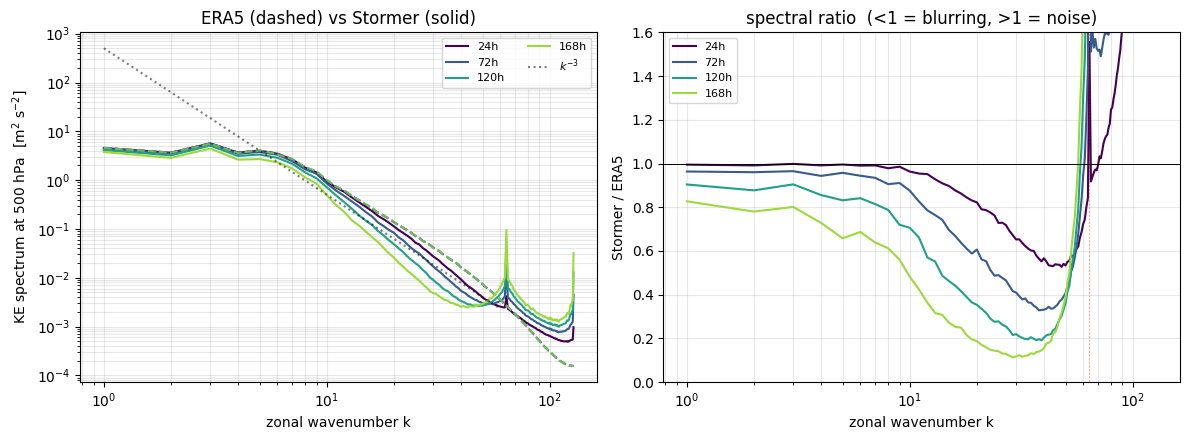

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
lead_times = sorted(ke_pred_mean)
colors = plt.cm.viridis(np.linspace(0, 0.85, len(lead_times)))

for c, lt in zip(colors, lead_times):
    ax1.loglog(k_axis, ke_gt_mean[lt],   color=c, ls='--', alpha=0.6)
    ax1.loglog(k_axis, ke_pred_mean[lt], color=c, ls='-',  label=f'{lt}h')

# k^-3 synoptic-scale reference
ref = ke_gt_mean[lead_times[0]][4] * (k_axis / 5.0) ** -3
ax1.loglog(k_axis[k_axis < 60], ref[k_axis < 60], 'k:', alpha=0.5, label=r'$k^{-3}$')
ax1.set(xlabel='zonal wavenumber k', ylabel=r'KE spectrum at 500 hPa  [m$^2$ s$^{-2}$]',
        title='ERA5 (dashed) vs Stormer (solid)')
ax1.legend(fontsize=8, ncol=2); ax1.grid(True, which='both', alpha=0.3)

for c, lt in zip(colors, lead_times):
    ax2.semilogx(k_axis, ke_pred_mean[lt] / ke_gt_mean[lt], color=c, label=f'{lt}h')
ax2.axhline(1, color='k', lw=0.7)
ax2.axvline(64, color='r', lw=0.5, ls='--', alpha=0.5)   # patch artifact
ax2.set(xlabel='zonal wavenumber k', ylabel='Stormer / ERA5',
        title='spectral ratio  (<1 = blurring, >1 = noise)',
        ylim=(0, 1.6))
ax2.legend(fontsize=8); ax2.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


In [23]:
import pyshtools as pysh

# Sanity check the grid orientation pyshtools expects: lat[0] should be +90 (north pole).
# If your `lat` array starts negative, flip both u and v along axis 0 before SH expansion.
import pyshtools as pysh

# Stormer/ERA5 lat runs -90 → +90; pyshtools needs +90 → -90. Flip on the fly.
LAT_FLIP = lat[0] < lat[-1]
assert pred.shape[-1] == 2 * pred.shape[-2], "Need DH2 grid: nlon == 2*nlat"

def sh_ke_spectrum(u, v):
    if LAT_FLIP:
        u = u[::-1]
        v = v[::-1]
    clm_u = pysh.expand.SHExpandDH(np.ascontiguousarray(u, dtype=np.float64), sampling=2)
    clm_v = pysh.expand.SHExpandDH(np.ascontiguousarray(v, dtype=np.float64), sampling=2)
    E = 0.5 * (pysh.spectralanalysis.spectrum(clm_u) +
               pysh.spectralanalysis.spectrum(clm_v))
    n = np.arange(E.size)
    return n[1:], E[1:]


sh_pred_by_lt = defaultdict(list)
sh_gt_by_lt   = defaultdict(list)
n_axis = None

for fpath in sorted(_glob.glob(os.path.join(out_dir, '20*.pt'))):
    blob = torch.load(fpath, weights_only=False)
    for lt, data in blob['results'].items():
        pred = data['pred'][0]; gt = data['gt'][0]
        u_p, v_p = denorm(pred[ui], ui), denorm(pred[vi], vi)
        u_g, v_g = denorm(gt[ui],   ui), denorm(gt[vi],   vi)
        n, ep = sh_ke_spectrum(u_p, v_p)
        _, eg = sh_ke_spectrum(u_g, v_g)
        sh_pred_by_lt[lt].append(ep); sh_gt_by_lt[lt].append(eg); n_axis = n

sh_pred_mean = {lt: np.mean(np.stack(v), 0) for lt, v in sh_pred_by_lt.items()}
sh_gt_mean   = {lt: np.mean(np.stack(v), 0) for lt, v in sh_gt_by_lt.items()}
print(f"SH spectra up to n={n_axis.max()} "
      f"(grid limit: nlat/2 − 1 = {pred.shape[-2]//2 - 1})")


SH spectra up to n=63 (grid limit: nlat/2 − 1 = 63)


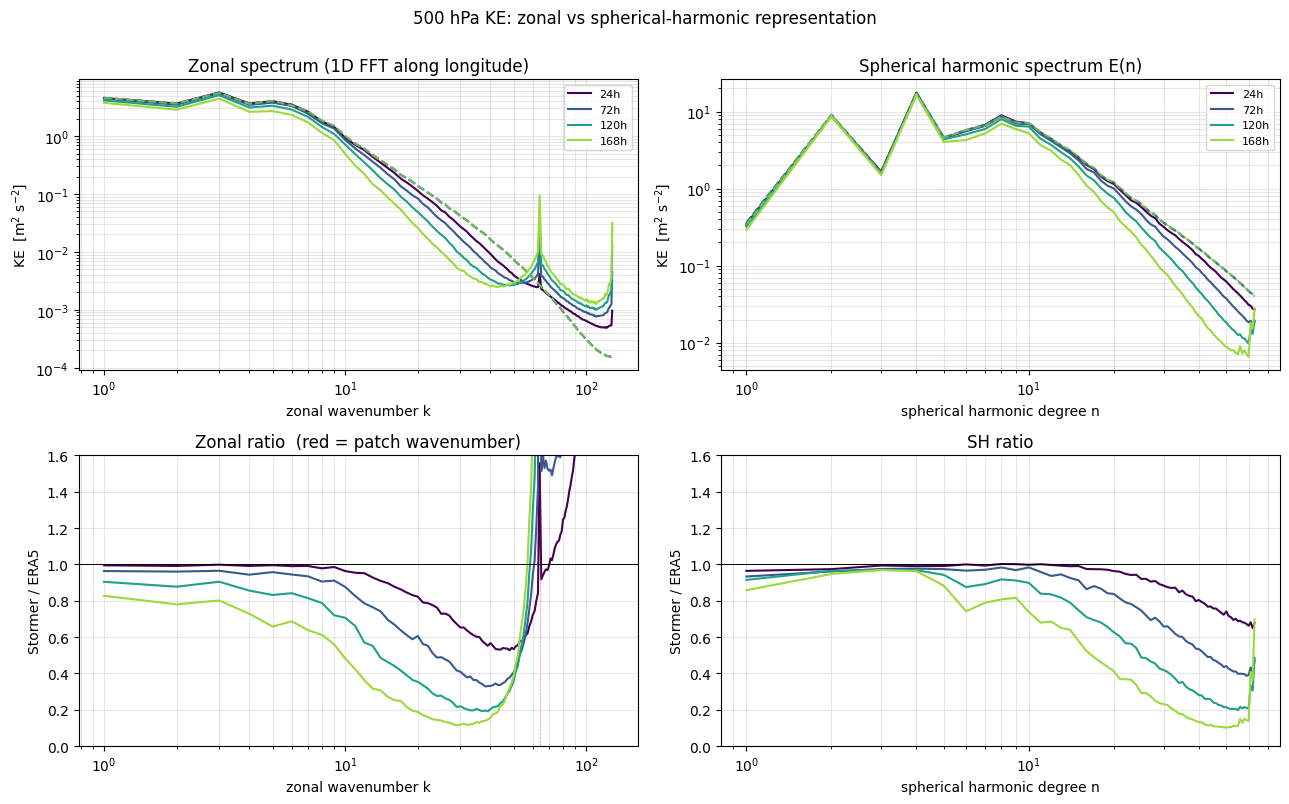

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
lead_times = sorted(ke_pred_mean)
colors = plt.cm.viridis(np.linspace(0, 0.85, len(lead_times)))

# top-left: zonal spectra
for c, lt in zip(colors, lead_times):
    axes[0, 0].loglog(k_axis, ke_gt_mean[lt],   color=c, ls='--', alpha=0.6)
    axes[0, 0].loglog(k_axis, ke_pred_mean[lt], color=c, ls='-',  label=f'{lt}h')
axes[0, 0].set(xlabel='zonal wavenumber k', ylabel=r'KE  [m$^2$ s$^{-2}$]',
               title='Zonal spectrum (1D FFT along longitude)')
axes[0, 0].legend(fontsize=8); axes[0, 0].grid(True, which='both', alpha=0.3)

# top-right: SH spectra
for c, lt in zip(colors, lead_times):
    axes[0, 1].loglog(n_axis, sh_gt_mean[lt],   color=c, ls='--', alpha=0.6)
    axes[0, 1].loglog(n_axis, sh_pred_mean[lt], color=c, ls='-',  label=f'{lt}h')
axes[0, 1].set(xlabel='spherical harmonic degree n', ylabel=r'KE  [m$^2$ s$^{-2}$]',
               title='Spherical harmonic spectrum E(n)')
axes[0, 1].legend(fontsize=8); axes[0, 1].grid(True, which='both', alpha=0.3)

# bottom-left: zonal ratio
for c, lt in zip(colors, lead_times):
    axes[1, 0].semilogx(k_axis, ke_pred_mean[lt] / ke_gt_mean[lt], color=c, label=f'{lt}h')
axes[1, 0].axhline(1, color='k', lw=0.7); axes[1, 0].axvline(64, color='r', lw=0.5, ls='--', alpha=0.5)
axes[1, 0].set(xlabel='zonal wavenumber k', ylabel='Stormer / ERA5',
               title='Zonal ratio  (red = patch wavenumber)', ylim=(0, 1.6))
axes[1, 0].grid(True, which='both', alpha=0.3)

# bottom-right: SH ratio
for c, lt in zip(colors, lead_times):
    axes[1, 1].semilogx(n_axis, sh_pred_mean[lt] / sh_gt_mean[lt], color=c, label=f'{lt}h')
axes[1, 1].axhline(1, color='k', lw=0.7)
axes[1, 1].set(xlabel='spherical harmonic degree n', ylabel='Stormer / ERA5',
               title='SH ratio', ylim=(0, 1.6))
axes[1, 1].grid(True, which='both', alpha=0.3)

plt.suptitle('500 hPa KE: zonal vs spherical-harmonic representation', y=1.00)
plt.tight_layout(); plt.show()


In [10]:
import datetime
import torch

In [102]:
all_metrics = torch.load("all_metrics.pt", weights_only=False)

In [13]:
var = "10m_u_component_of_wind"
log_postfix = 24

In [28]:
all_metrics[datetime.datetime(2020, 1, 26, 0, 0)][log_postfix]

{'RMSE': {'w_rmse_2m_temperature_24': tensor(0.6354),
  'w_rmse_10m_u_component_of_wind_24': tensor(0.7864),
  'w_rmse_10m_v_component_of_wind_24': tensor(0.7960),
  'w_rmse_mean_sea_level_pressure_24': tensor(59.9967),
  'w_rmse_geopotential_50_24': tensor(186.4756),
  'w_rmse_geopotential_100_24': tensor(102.7691),
  'w_rmse_geopotential_150_24': tensor(79.4529),
  'w_rmse_geopotential_200_24': tensor(71.6700),
  'w_rmse_geopotential_250_24': tensor(69.6812),
  'w_rmse_geopotential_300_24': tensor(69.7870),
  'w_rmse_geopotential_400_24': tensor(64.3798),
  'w_rmse_geopotential_500_24': tensor(54.8597),
  'w_rmse_geopotential_600_24': tensor(47.6947),
  'w_rmse_geopotential_700_24': tensor(45.0923),
  'w_rmse_geopotential_850_24': tensor(44.1429),
  'w_rmse_geopotential_925_24': tensor(45.0496),
  'w_rmse_geopotential_1000_24': tensor(47.5180),
  'w_rmse_u_component_of_wind_50_24': tensor(2.2365),
  'w_rmse_u_component_of_wind_100_24': tensor(2.0606),
  'w_rmse_u_component_of_wind_15

In [29]:
import torch
from collections import defaultdict

all_metrics = torch.load("all_metrics.pt", weights_only=False)

mean_rmse = defaultdict(dict)
for lead_time in next(iter(all_metrics.values())).keys():
    all_keys = list(next(iter(all_metrics.values()))[lead_time]["RMSE"].keys())
    for key in all_keys:
        values = [all_metrics[date][lead_time]["RMSE"][key].item() for date in all_metrics]
        mean_rmse[lead_time][key] = sum(values) / len(values)


In [47]:
mean_rmse

defaultdict(dict,
            {24: {'w_rmse_2m_temperature_24': 0.6350440447745116,
              'w_rmse_10m_u_component_of_wind_24': 0.7665846822918325,
              'w_rmse_10m_v_component_of_wind_24': 0.8040754587753959,
              'w_rmse_mean_sea_level_pressure_24': 60.27684217259504,
              'w_rmse_geopotential_50_24': 132.87800150332242,
              'w_rmse_geopotential_100_24': 82.03265563301419,
              'w_rmse_geopotential_150_24': 68.65695132379946,
              'w_rmse_geopotential_200_24': 65.62399186949798,
              'w_rmse_geopotential_250_24': 66.80976646533911,
              'w_rmse_geopotential_300_24': 68.09966568324877,
              'w_rmse_geopotential_400_24': 60.240074461784914,
              'w_rmse_geopotential_500_24': 51.261107569155484,
              'w_rmse_geopotential_600_24': 45.760015902311906,
              'w_rmse_geopotential_700_24': 43.66466204325358,
              'w_rmse_geopotential_850_24': 43.10930406874505,
        

In [32]:
import matplotlib.pyplot as plt

In [50]:
metrics_to_cals = all_metrics[datetime.datetime(2020, 1, 26, 0, 0)][24]
metrics_to_cals.keys()

dict_keys(['RMSE', 'bias', 'lat_weighted_rmsb', 'power spectrum'])

In [42]:
wavenumbers = metrics_to_cals['power spectrum']['wavenumbers_geopotential_500_24']
psd = metrics_to_cals['power spectrum']['spectral_ratio_geopotential_500_24']

In [78]:
all_metrics[datetime.datetime(2020, 1, 26, 0, 0)][lts]['power spectrum'].keys()

dict_keys(['psd_preds_2m_temperature_24', 'psd_truth_2m_temperature_24', 'wavenumbers_2m_temperature_24', 'spectral_ratio_2m_temperature_24', 'psd_preds_10m_u_component_of_wind_24', 'psd_truth_10m_u_component_of_wind_24', 'wavenumbers_10m_u_component_of_wind_24', 'spectral_ratio_10m_u_component_of_wind_24', 'psd_preds_10m_v_component_of_wind_24', 'psd_truth_10m_v_component_of_wind_24', 'wavenumbers_10m_v_component_of_wind_24', 'spectral_ratio_10m_v_component_of_wind_24', 'psd_preds_mean_sea_level_pressure_24', 'psd_truth_mean_sea_level_pressure_24', 'wavenumbers_mean_sea_level_pressure_24', 'spectral_ratio_mean_sea_level_pressure_24', 'psd_preds_geopotential_50_24', 'psd_truth_geopotential_50_24', 'wavenumbers_geopotential_50_24', 'spectral_ratio_geopotential_50_24', 'psd_preds_geopotential_100_24', 'psd_truth_geopotential_100_24', 'wavenumbers_geopotential_100_24', 'spectral_ratio_geopotential_100_24', 'psd_preds_geopotential_150_24', 'psd_truth_geopotential_150_24', 'wavenumbers_geop

In [ ]:
KEY_VARS = {
    "Z500":  "geopotential_500",
    "T850":  "temperature_850",
    "T2M":   "2m_temperature",
    "U10":   "10m_u_component_of_wind",
    "V10":   "10m_v_component_of_wind",
    "MSLP":  "mean_sea_level_pressure",
    "U500":  "u_component_of_wind_500",
    "V500":  "v_component_of_wind_500",
    "Q700":  "specific_humidity_700",
    "T500":  "temperature_500",
}

In [101]:
lts = 24gf
gfdg n
for key, varfdgs in KEY_VARS.items():
    wavenumbers = all_metrics[datetime.datetime(2020, 1, 26, 0, 0)][lts]['power spectrum'][f'wavenumbers_{vars}_{lts}']
    psd = all_metrics[datetime.datetime(2020, 1, 26, 0, 0)][lts]['power spectrum'][f'spectral_ratio_{vars}_{lts}']
    plt.plot(wavenumbers, psd)
    plt.title(f'variable: {key}')
    plt.show()

SyntaxError: invalid decimal literal (1693633903.py, line 1)

In [74]:
log_postfix = 24
diff = all_metrics[datetime.datetime(2020, 1, 2, 0, 0)][log_postfix]['bias'][f'bias_10m_u_component_of_wind_{log_postfix}'].squeeze(0)
diff.numpy()

array([[-0.49086797, -1.0070795 , -0.8643545 , ..., -0.8883643 ,
        -0.6576028 , -0.6202543 ],
       [-0.6069155 , -0.9203774 , -0.93238235, ..., -0.73230004,
        -0.73763585, -0.33613777],
       [-0.39749622, -0.63892865, -0.7629795 , ..., -0.51354384,
        -0.6082492 , -0.4922018 ],
       ...,
       [-0.41350293, -0.6709418 , -0.6962857 , ..., -0.82433796,
        -0.84568024, -0.5282166 ],
       [-0.32813454, -0.76698136, -0.86835647, ..., -0.6696081 ,
        -0.7549763 , -0.4695258 ],
       [-0.29878926, -0.5535604 , -0.9537246 , ..., -0.42684197,
        -0.7869897 , -0.4441824 ]], shape=(128, 256), dtype=float32)

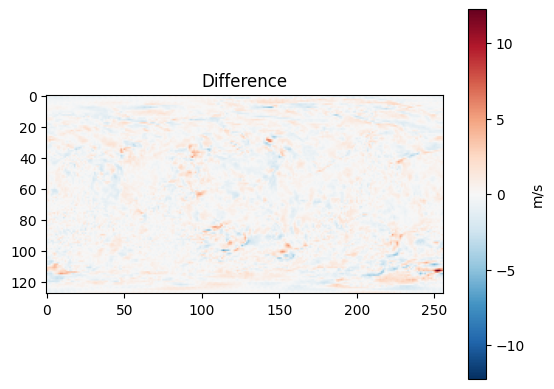

In [75]:
vmax = diff.abs().max().item()
plt.imshow(diff, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
plt.title("Difference")
plt.colorbar(label="m/s")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dates = list(all_metrics.keys())
lead_times = sorted(next(iter(all_metrics.values())).keys())  # [24, 72, 120, 168]
LEVELS_HPA = [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]

KEY_VARS = {
    "T2M":   "2m_temperature",
    "U10":   "10m_u_component_of_wind",
    "V10":   "10m_v_component_of_wind",
    "MSLP":  "mean_sea_level_pressure",
    "Z500":  "geopotential_500",
    "T850":  "temperature_850",
    "Q700":  "specific_humidity_700",
    "U500":  "u_component_of_wind_500",
    "V500":  "v_component_of_wind_500",
}


In [108]:
dates = list(all_metrics.keys())
lead_times = list(all_metrics[dates[0]].keys())
lead_times

[24, 72, 120, 168]

In [109]:
key_vars = {
    "T2M":   "2m_temperature",
    "U10":   "10m_u_component_of_wind",
    "V10":   "10m_v_component_of_wind",
    "MSLP":  "mean_sea_level_pressure",
    "Z500":  "geopotential_500",
    "T850":  "temperature_850",
    "Q700":  "specific_humidity_700",
    "U500":  "u_component_of_wind_500",
    "V500":  "v_component_of_wind_500",
}

len(key_vars)

9

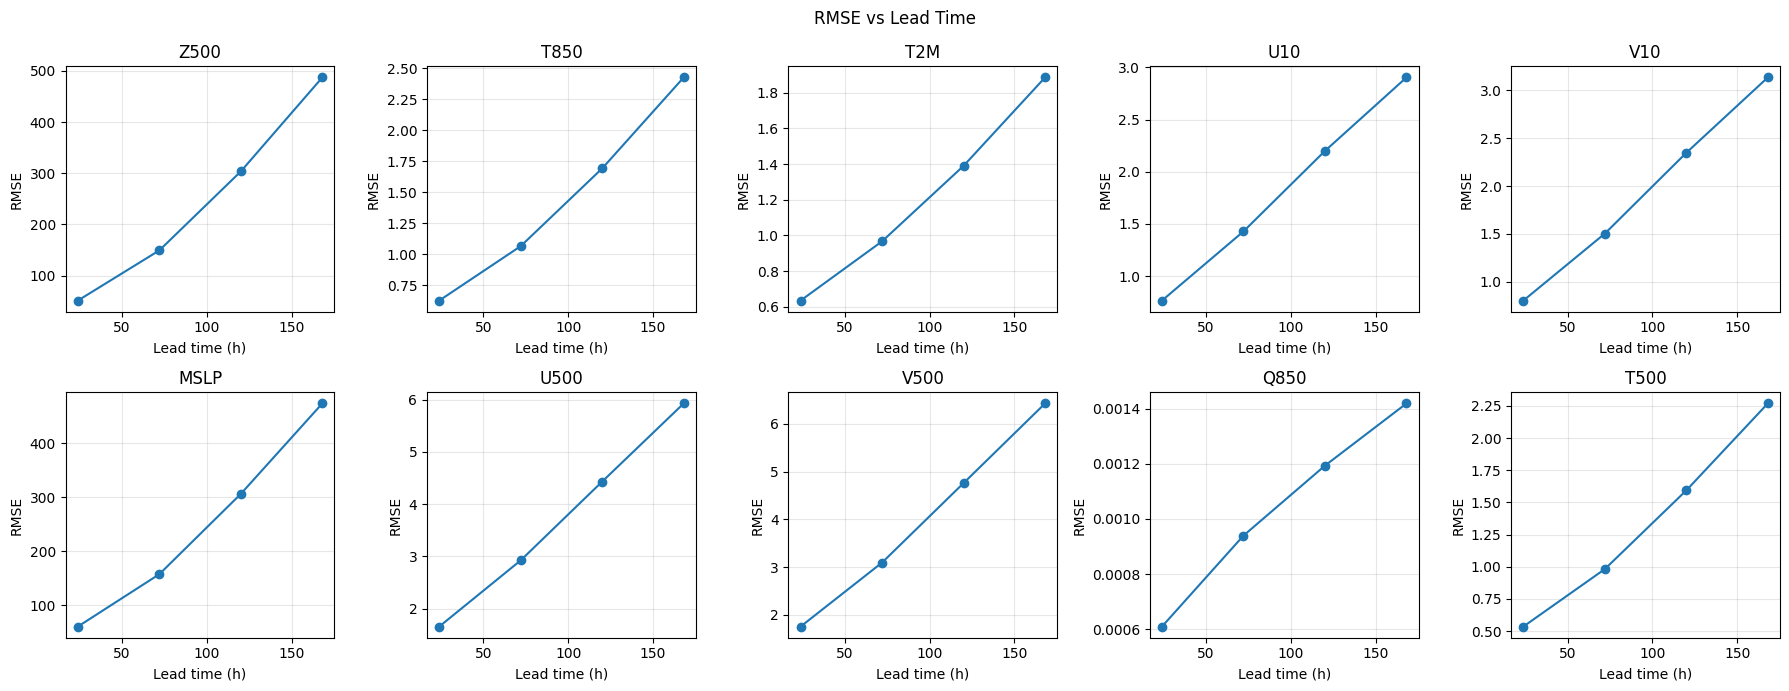

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
for ax, (label, var) in zip(axes.flat, KEY_VARS.items()):
    rmse_per_lt = []
    for lt in lead_times:
        vals = [all_metrics[d][lt]["RMSE"][f"w_rmse_{var}_{lt}"].item() for d in dates]
        rmse_per_lt.append(np.mean(vals))
    ax.plot(lead_times, rmse_per_lt, marker='o')
    ax.set_title(label)
    ax.set_xlabel("Lead time (h)")
    ax.set_ylabel("RMSE")
    ax.grid(True, alpha=0.3)
plt.suptitle("RMSE vs Lead Time")
plt.tight_layout()
plt.show()


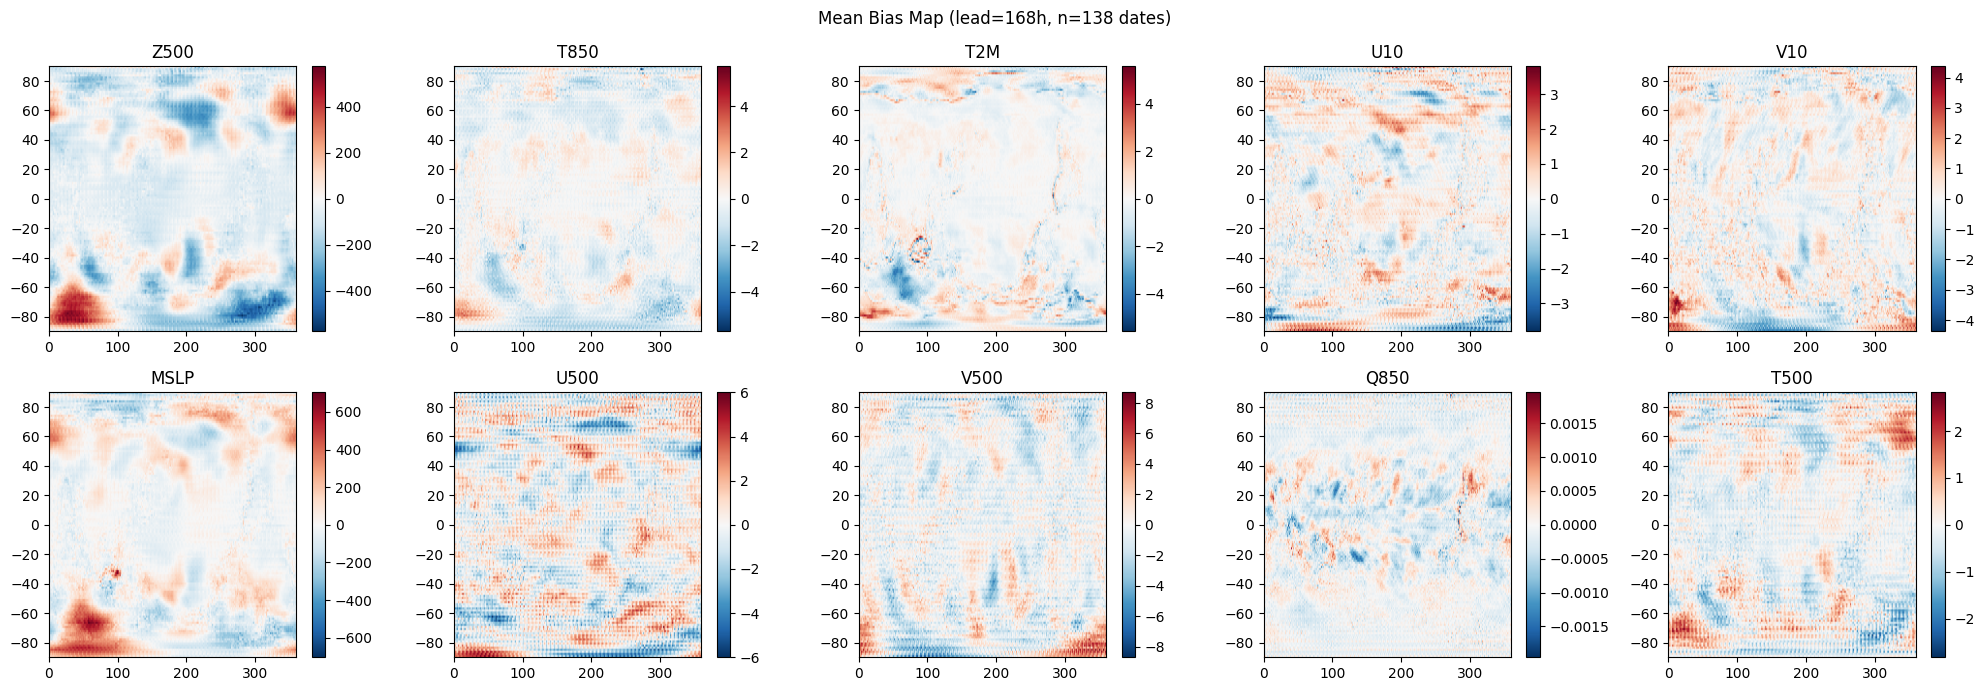

In [100]:
lt = 168  # change as needed
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, (label, var) in zip(axes.flat, KEY_VARS.items()):
    maps = [all_metrics[d][lt]["bias"][f"bias_{var}_{lt}"].squeeze(0).numpy() for d in dates]
    mean_bias = np.mean(maps, axis=0)  # [H, W]
    vmax = np.abs(mean_bias).max()
    im = ax.imshow(mean_bias, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   extent=[0, 360, -90, 90], origin="upper", aspect="auto")
    ax.set_title(label)
    plt.colorbar(im, ax=ax)
plt.suptitle(f"Mean Bias Map (lead={lt}h, n={len(dates)} dates)")
plt.tight_layout()
plt.show()


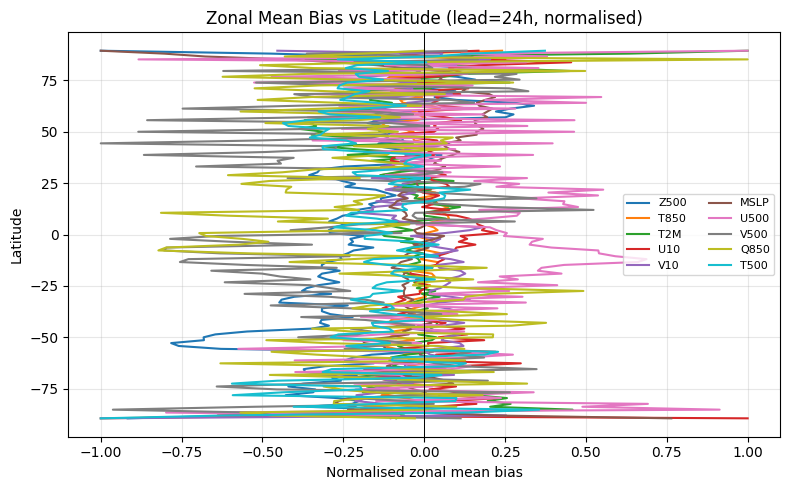

In [99]:
lt = 24
import os
lat = np.load(os.path.join(root_dir, "lat.npy"))
lon = np.load(os.path.join(root_dir, "lon.npy"))


fig, ax = plt.subplots(figsize=(8, 5))
for label, var in KEY_VARS.items():
    maps = [all_metrics[d][lt]["bias"][f"bias_{var}_{lt}"].squeeze(0).numpy() for d in dates]
    zonal = np.mean(maps, axis=0).mean(axis=-1)  # mean over lon → [H]
    zonal_norm = zonal / np.abs(zonal).max()      # normalise so all fit on one plot
    ax.plot(zonal_norm, lat, label=label)
ax.axvline(0, color='k', lw=0.7)
ax.set_xlabel("Normalised zonal mean bias")
ax.set_ylabel("Latitude")
ax.set_title(f"Zonal Mean Bias vs Latitude (lead={lt}h, normalised)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


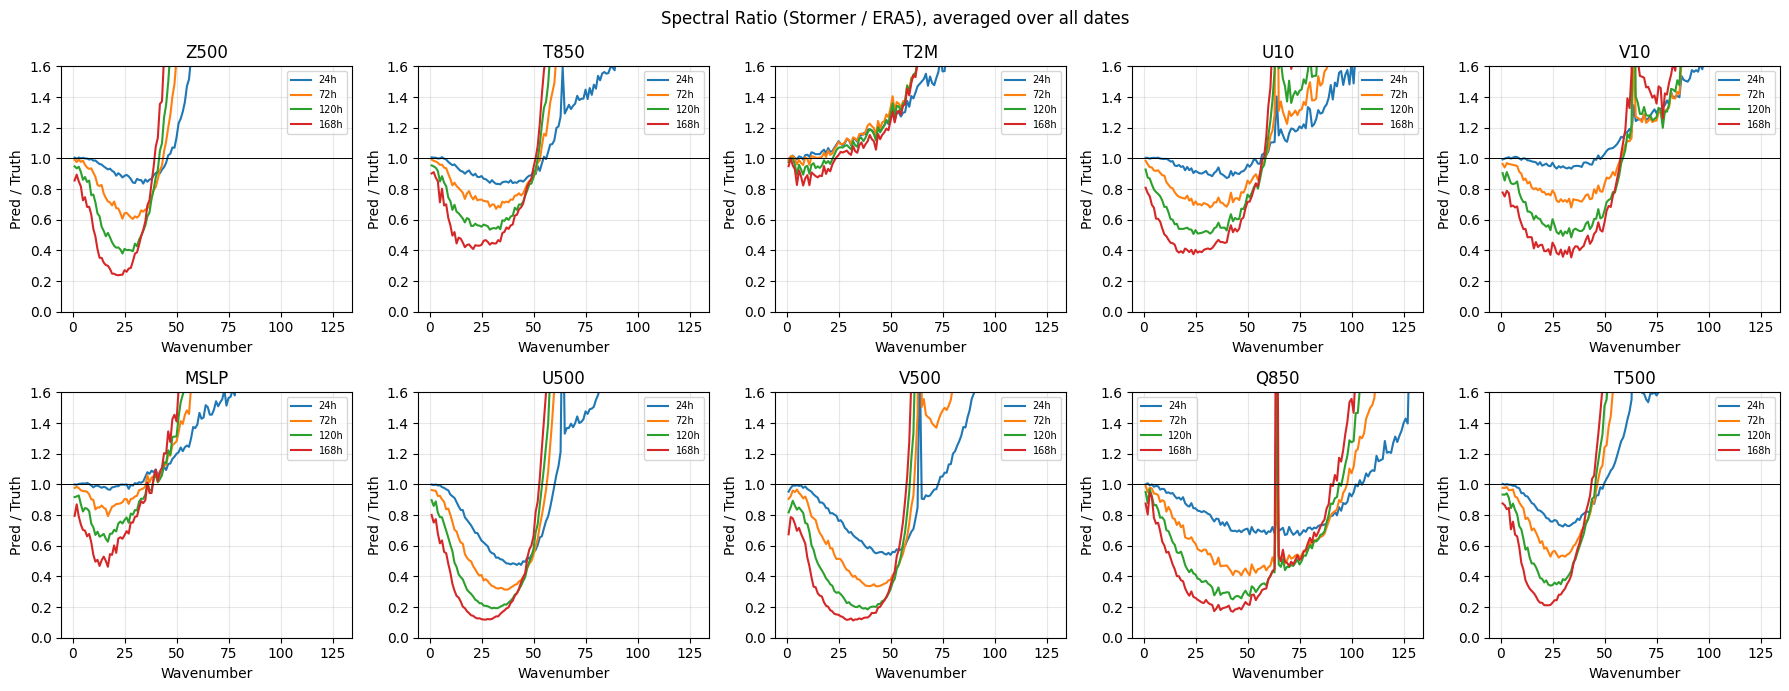

In [103]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, (label, var) in zip(axes.flat, KEY_VARS.items()):
    for lt in lead_times:
        ratios = [all_metrics[d][lt]["power spectrum"][f"spectral_ratio_{var}_{lt}"].numpy()
                  for d in dates]
        mean_ratio = np.mean(ratios, axis=0)
        wn = all_metrics[dates[0]][lt]["power spectrum"][f"wavenumbers_{var}_{lt}"].numpy()
        ax.plot(wn, mean_ratio, label=f"{lt}h")
    ax.axhline(1, color='k', lw=0.7)
    ax.set_title(label)
    ax.set_xlabel("Wavenumber")
    ax.set_ylabel("Pred / Truth")
    ax.set_ylim(0, 1.6)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
plt.suptitle("Spectral Ratio (Stormer / ERA5), averaged over all dates")
plt.tight_layout()
plt.show()


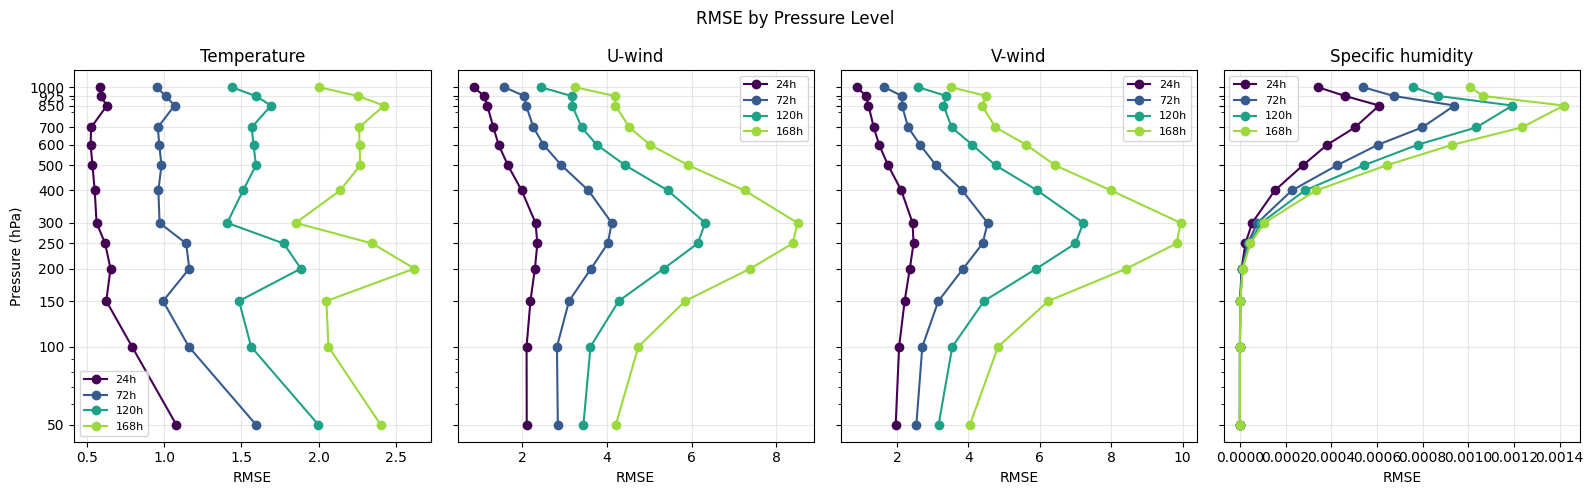

In [98]:
PRESSURE_VARS = {
    "Temperature": "temperature",
    "U-wind":      "u_component_of_wind",
    "V-wind":      "v_component_of_wind",
    "Specific humidity": "specific_humidity",
}
colors = plt.cm.viridis(np.linspace(0, 0.85, len(lead_times)))

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, (name, prefix) in zip(axes, PRESSURE_VARS.items()):
    for c, lt in zip(colors, lead_times):
        rmse_per_level = []
        for lev in LEVELS_HPA:
            var = f"{prefix}_{lev}"
            vals = [all_metrics[d][lt]["RMSE"][f"w_rmse_{var}_{lt}"].item() for d in dates]
            rmse_per_level.append(np.mean(vals))
        ax.plot(rmse_per_level, LEVELS_HPA, marker='o', color=c, label=f"{lt}h")
    ax.invert_yaxis()
    ax.set_yscale("log")
    ax.set_yticks(LEVELS_HPA)
    ax.set_yticklabels(LEVELS_HPA)
    ax.set_title(name)
    ax.set_xlabel("RMSE")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Pressure (hPa)")
plt.suptitle("RMSE by Pressure Level")
plt.tight_layout()
plt.show()
